## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [601]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 50
seed = int(time.time())  # 每分钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 50 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,11.9
1,2,9.4
2,3,-21.1
3,4,33.2
4,5,-11.1


### **第一步：导入包**

In [602]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **第二步：导入数据**

In [603]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x      y
0    1   11.9
1    2    9.4
2    3  -21.1
3    4   33.2
4    5  -11.1
5    6    4.7
6    7    6.5
7    8  -35.8
8    9  -17.9
9   10   13.1
10  11  -23.4
11  12  -17.1
12  13  -55.0
13  14  -29.3
14  15  -14.9
15  16  -46.9
16  17  -26.6
17  18  -41.9
18  19  -55.1
19  20  -36.7
20  21  -35.7
21  22  -61.7
22  23  -57.3
23  24  -45.4
24  25  -40.2
25  26  -56.2
26  27  -79.5
27  28  -89.5
28  29  -88.8
29  30  -72.2
30  31 -116.6
31  32  -71.2
32  33  -99.4
33  34  -96.9
34  35 -116.5
35  36  -90.6
36  37 -113.6
37  38  -98.8
38  39 -124.3
39  40 -117.2
40  41  -91.6
41  42 -101.8
42  43  -80.8
43  44 -103.8
44  45 -107.5
45  46 -132.1
46  47 -113.8
47  48 -108.5
48  49 -140.7
49  50 -127.6


#### 试着画个散点图？

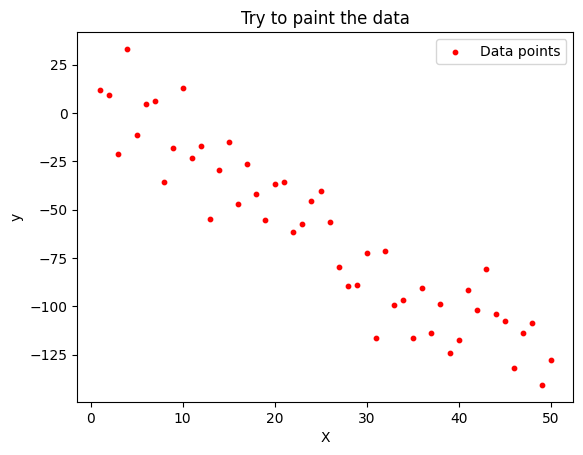

In [610]:
plt.scatter(X, y, color='red', s=10, label='Data points')
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 划分一下训练数据和测试数据~

In [605]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [606]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [607]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=-2.9745, b=14.9466
True parameters: a=-2.7266, b=6.8944
Test MSE: 236.2545


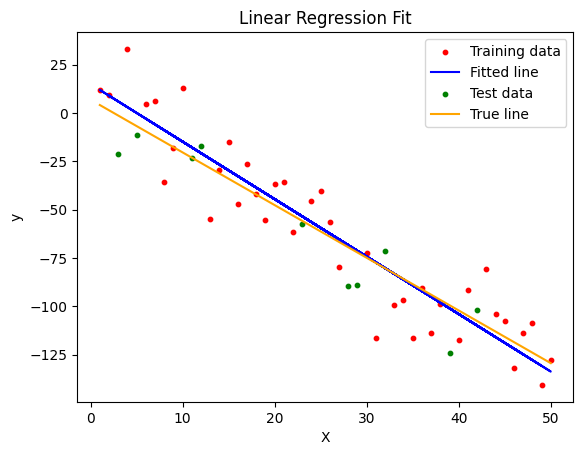

In [608]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: a={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')